In [1]:
import pandas as pd
from datetime import datetime, timedelta
import os

In [ ]:
# 파일들이 들어있는 폴더 경로 (현재 폴더면 '.')
folder_path = './xlsx'  # 엑셀 파일들을 모아둔 폴더명으로 수정
file_list = sorted([f for f in os.listdir(folder_path) if f.endswith('.xlsx')])

all_data = []
# 전체 프로젝트의 시작 날짜 (2025년 2월 1일)
current_date = datetime(2025, 2, 1)

print(f"총 {len(file_list)}개의 파일을 처리합니다.")

# 파일별 반복문
for file_name in file_list:
    file_full_path = os.path.join(folder_path, file_name)
    print(f"현재 처리 중: {file_name}")
    
    # 엑셀의 모든 시트 불러오기
    all_sheets = pd.read_excel(file_full_path, sheet_name=None, header=None)
    sheet_items = list(all_sheets.items())[2:]  # 두 번째 시트부터 추출
    
    # 시트별 반복문
    for sheet_name, df in sheet_items:
        try:
            # 데이터 추출 (좌표 동일)
            daily_sales = df.iloc[24, 0]        # A25
            labor_cost = df.iloc[26, 8]         # I27
            material_cost = df.iloc[22, 8]      # I23
            other_expense = df.iloc[22, 10]     # K23
            table_count = df.iloc[19, 5]        # F20
            
            all_data.append({
                'Date': current_date.strftime('%Y%m%d'),
                'Sales': daily_sales,
                'Labor_Cost': labor_cost,
                'Material_Cost': material_cost,
                'Other_Expense': other_expense,
                'Table_Count': table_count
            })
            
            # 날짜를 하루씩 증가
            current_date += timedelta(days=1)
            
        except Exception as e:
            print(f"오류 발생 - 파일: {file_name}, 시트: {sheet_name}, 내용: {e}")

# 최종 데이터프레임 생성 및 저장
final_df = pd.DataFrame(all_data)

# 숫자형 데이터로 변환 (추출 시 문자로 인식될 경우를 대비)
cols_to_fix = ['Sales', 'Labor_Cost', 'Material_Cost', 'Other_Expense', 'Table_Count']
final_df[cols_to_fix] = final_df[cols_to_fix].apply(pd.to_numeric, errors='coerce').fillna(0)

final_df.to_excel('meat_data.xlsx', index=False)

print("-" * 30)
print(f"전체 처리 완료!")
print(f"총 추출된 일수: {len(final_df)}일")

총 12개의 파일을 처리합니다.
현재 처리 중: 202502.xlsx
오류 발생 - 파일: 202502.xlsx, 시트: Chart1, 내용: index 0 is out of bounds for axis 0 with size 0
현재 처리 중: 202503.xlsx
오류 발생 - 파일: 202503.xlsx, 시트: Chart1, 내용: index 0 is out of bounds for axis 0 with size 0
현재 처리 중: 202504.xlsx
오류 발생 - 파일: 202504.xlsx, 시트: Chart1, 내용: index 0 is out of bounds for axis 0 with size 0
현재 처리 중: 202505.xlsx
오류 발생 - 파일: 202505.xlsx, 시트: Chart1, 내용: index 0 is out of bounds for axis 0 with size 0
현재 처리 중: 202506.xlsx
오류 발생 - 파일: 202506.xlsx, 시트: Chart1, 내용: index 0 is out of bounds for axis 0 with size 0
현재 처리 중: 202507.xlsx
오류 발생 - 파일: 202507.xlsx, 시트: Chart1, 내용: index 0 is out of bounds for axis 0 with size 0
현재 처리 중: 202508.xlsx
오류 발생 - 파일: 202508.xlsx, 시트: Chart1, 내용: index 0 is out of bounds for axis 0 with size 0
현재 처리 중: 202509.xlsx
오류 발생 - 파일: 202509.xlsx, 시트: Chart1, 내용: index 0 is out of bounds for axis 0 with size 0
현재 처리 중: 202510.xlsx
오류 발생 - 파일: 202510.xlsx, 시트: Chart1, 내용: index 0 is out of bounds for axis 0 with

In [2]:
df = pd.read_excel('C:\Demand_prediction_MLproject\data\meat_data.xlsx')
pd.DataFrame(df)

,Date,Sales,Labor_Cost,Material_Cost,Other_Expense,Table_Count
0,20250201,4665000.0,866235.714286,3030269,114785.285714,62.0
1,20250202,2765500.0,814835.714286,0,202204.285714,40.0
2,20250203,2237000.0,850285.714286,499818,66754.285714,38.0
3,20250204,4134000.0,824285.714286,2915674,118634.285714,59.0
4,20250205,3536000.0,876285.714286,1120400,228574.285714,44.0
...,...,...,...,...,...,...
360,20260127,4553600.0,633741.935484,885628,148000.000000,41.0
361,20260128,4581800.0,635741.935484,555890,135351.000000,59.0
362,20260129,4376500.0,484741.935484,1854652,30000.000000,59.0
363,20260130,5328700.0,640241.935484,2568562,31900.000000,69.0


In [3]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d')

In [4]:
df['Labor_Cost'] = df['Labor_Cost'].round(-2)
df['Other_Expense'] = df['Other_Expense'].round(-2)

In [ ]:
df.rename(columns = {
    'Date' : '날짜', 
    'Sales' : '일매출', 
    'Labor_Cost' : '인건비용', 
    'Material_Cost' : '식자재비용', 
    'Other_Expense' : '기타비용', 
    'Table_Count' : '테이블수'}, 
    inplace = True)

In [6]:
df_weather = pd.read_csv('C:\Demand_prediction_MLproject\data\seoul_weather.csv', encoding='cp949')
df_weather

,지점,지점명,일시,평균기온(°C),강수 계속시간(hr)
0,108,서울,2025-02-01,1.6,NaN
1,108,서울,2025-02-02,1.5,0.08
2,108,서울,2025-02-03,-4.1,NaN
3,108,서울,2025-02-04,-9.0,NaN
4,108,서울,2025-02-05,-8.6,NaN
...,...,...,...,...,...
360,108,서울,2026-01-27,-4.4,NaN
361,108,서울,2026-01-28,-5.4,NaN
362,108,서울,2026-01-29,-5.2,NaN
363,108,서울,2026-01-30,-6.4,NaN


In [7]:
df_weather.rename(columns = {'일시' : '날짜'}, inplace = True)

In [8]:
df_weather['날짜'] = pd.to_datetime(df_weather['날짜'], format='%Y-%m-%d')

In [9]:
df = pd.merge(df, df_weather, on = '날짜', how = 'inner')

In [11]:
df.drop(['지점', '지점명'], axis=1, inplace=True)

In [12]:
df.rename(columns = {'평균기온(°C)' : '평균기온', '강수 계속시간(hr)' : '강수계속시간'}, inplace = True)

In [13]:
df_cpi = pd.read_csv('C:\Demand_prediction_MLproject\data\CPI.csv', encoding = 'cp949')
df_cpi.head()

,통계표,계정항목,단위,가중치,변환,Feb-25,Mar-25,Apr-25,May-25,Jun-25,Jul-25,Aug-25,Sep-25,Oct-25,Nov-25,Dec-25,Jan-26
0,4.2.1. 소비자물가지수,쌀,2020=100,4.2,원자료,99.88,100.89,102.05,102.76,104.69,107.93,109.69,113.98,120.31,118.42,117.50,116.84
1,4.2.1. 소비자물가지수,두부,2020=100,1.2,원자료,117.12,110.36,110.91,110.98,110.36,111.01,110.16,109.93,110.13,109.36,108.28,109.10
2,4.2.1. 소비자물가지수,육류,2020=100,28.6,원자료,118.10,117.55,118.69,120.63,121.95,122.19,124.61,124.76,125.69,123.03,124.07,124.22
3,4.2.1. 소비자물가지수,달걀,2020=100,3.0,원자료,132.71,131.93,136.98,139.36,142.49,144.79,145.31,145.90,144.62,144.25,143.52,142.34
4,4.2.1. 소비자물가지수,식용유지,2020=100,1.4,원자료,168.22,165.62,166.21,161.76,159.86,156.09,158.49,159.00,155.50,157.50,153.67,154.17


In [14]:
df_cpi['계정항목'].unique()

array(['        쌀', '        두부', '      육류', '        달걀', '      식용유지',
       '        배', '      채소 및 해조', '      기타 식료품', '        탄산음료',
       '      주류'], dtype=object)

In [15]:
df_cpi['계정항목'] = [x.strip() for x in df_cpi['계정항목']]

In [16]:
df_cpi['계정항목'].unique()

array(['쌀', '두부', '육류', '달걀', '식용유지', '배', '채소 및 해조', '기타 식료품', '탄산음료',
       '주류'], dtype=object)

In [17]:
# 월 데이터 컬럼 추출 (Feb-25부터 Jan-26까지)
month_cols = ['Feb-25', 'Mar-25', 'Apr-25', 'May-25', 'Jun-25', 'Jul-25', 'Aug-25', 'Sep-25', 'Oct-25', 'Nov-25', 'Dec-25', 'Jan-26']


In [18]:
def weighted_average(row_indices):
    subset = df_cpi.iloc[row_indices]
    weights = subset['가중치']
    
    weighted_avg = {}

    for month in month_cols:
        weighted_sum = (subset[month] * weights).sum()
        total_weight = weights.sum()
        weighted_avg[month] = weighted_sum / total_weight
    return pd.Series(weighted_avg)

In [19]:
# 육류 가중 평균
meat_weighted_avg = weighted_average(2)

In [20]:
# 식료품 가중 평균 (쌀, 두부, 육류, 달걀, 식용유지) -> 고깃집 원가와 더 밀접
food_weighted_avg = weighted_average(range(5))

In [21]:
df_cpi_result = pd.DataFrame({
    '식료품가중평균' : food_weighted_avg,
    '육류가중평균' : meat_weighted_avg
})
df_cpi_result

,식료품가중평균,육류가중평균
Feb-25,119.045260,118.10
Mar-25,118.379115,117.55
Apr-25,119.788281,118.69
May-25,121.336719,120.63
Jun-25,122.686823,121.95
Jul-25,123.282500,122.19
Aug-25,125.378958,124.61
Sep-25,126.017396,124.76
Oct-25,127.181042,125.69
Nov-25,125.013125,123.03


In [22]:
df_cpi_result

,식료품가중평균,육류가중평균
Feb-25,119.045260,118.10
Mar-25,118.379115,117.55
Apr-25,119.788281,118.69
May-25,121.336719,120.63
Jun-25,122.686823,121.95
Jul-25,123.282500,122.19
Aug-25,125.378958,124.61
Sep-25,126.017396,124.76
Oct-25,127.181042,125.69
Nov-25,125.013125,123.03


In [23]:
df_cpi_result.rename(index = {
    'Feb-25' : 202502,
    'Mar-25' : 202503, 
    'Apr-25' : 202504,
    'May-25' : 202505, 
    'Jun-25' : 202506, 
    'Jul-25' : 202507, 
    'Aug-25' : 202508, 
    'Sep-25' : 202509, 
    'Oct-25' : 202510, 
    'Nov-25' : 202511, 
    'Dec-25' : 202512, 
    'Jan-26' : 202601 
}, inplace = True)

In [24]:
df['연월'] = df['날짜'].dt.strftime('%Y%m').astype(int)
df_cpi_result = df_cpi_result.reset_index()
df_cpi_result.columns = ['연월', '식료품가중평균', '육류가중평균']

In [25]:
df_cpi_result

,연월,식료품가중평균,육류가중평균
0,202502,119.045260,118.10
1,202503,118.379115,117.55
2,202504,119.788281,118.69
3,202505,121.336719,120.63
4,202506,122.686823,121.95
5,202507,123.282500,122.19
6,202508,125.378958,124.61
7,202509,126.017396,124.76
8,202510,127.181042,125.69
9,202511,125.013125,123.03


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   날짜      365 non-null    datetime64[ns]
 1   일매출     365 non-null    float64       
 2   인건비용    365 non-null    float64       
 3   식자재비용   365 non-null    int64         
 4   기타비용    365 non-null    float64       
 5   테이블수    358 non-null    float64       
 6   평균기온    365 non-null    float64       
 7   강수계속시간  157 non-null    float64       
 8   연월      365 non-null    int64         
dtypes: datetime64[ns](1), float64(6), int64(2)
memory usage: 25.8 KB


In [27]:
final_df = pd.merge(df, df_cpi_result, on='연월', how='left')
final_df = final_df.drop(columns=['연월'])

In [28]:
final_df = final_df.fillna(0)

In [29]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   날짜       365 non-null    datetime64[ns]
 1   일매출      365 non-null    float64       
 2   인건비용     365 non-null    float64       
 3   식자재비용    365 non-null    int64         
 4   기타비용     365 non-null    float64       
 5   테이블수     365 non-null    float64       
 6   평균기온     365 non-null    float64       
 7   강수계속시간   365 non-null    float64       
 8   식료품가중평균  365 non-null    float64       
 9   육류가중평균   365 non-null    float64       
dtypes: datetime64[ns](1), float64(8), int64(1)
memory usage: 28.6 KB


In [30]:
# !pip install holidays

In [31]:
import holidays

kr_holidays = holidays.KR(years = [2025, 2026])
holiday_list = [d.strftime('%Y-%m-%d') for d in kr_holidays]
print(holiday_list)

['2025-01-01', '2025-01-29', '2025-01-28', '2025-01-30', '2025-03-01', '2025-05-05', '2025-06-06', '2025-08-15', '2025-10-03', '2025-10-09', '2025-10-06', '2025-10-05', '2025-10-07', '2025-12-25', '2025-03-03', '2025-05-06', '2025-10-08', '2025-01-27', '2025-06-03', '2026-01-01', '2026-02-17', '2026-02-16', '2026-02-18', '2026-03-01', '2026-05-24', '2026-05-05', '2026-06-06', '2026-07-17', '2026-08-15', '2026-10-03', '2026-10-09', '2026-09-25', '2026-09-24', '2026-09-26', '2026-12-25', '2026-06-03', '2026-03-02', '2026-05-25', '2026-08-17', '2026-10-05']


In [32]:
# 요일 변수 생성 (0: 월요일, 6: 일요일)
final_df['요일'] = final_df['날짜'].dt.dayofweek

In [33]:
# 공휴일 여부 변수 생성
final_df['공휴일여부'] = final_df['날짜'].isin(holiday_list).astype(int)

C:\Users\신재호\AppData\Local\Temp\ipykernel_27320\3318492497.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  final_df['공휴일여부'] = final_df['날짜'].isin(holiday_list).astype(int)


In [34]:
print(final_df[['날짜', '요일', '공휴일여부']].head(10))

          날짜  요일  공휴일여부
0 2025-02-01   5      0
1 2025-02-02   6      0
2 2025-02-03   0      0
3 2025-02-04   1      0
4 2025-02-05   2      0
5 2025-02-06   3      0
6 2025-02-07   4      0
7 2025-02-08   5      0
8 2025-02-09   6      0
9 2025-02-10   0      0


In [35]:
final_df['공휴일전날'] = final_df['공휴일여부'].shift(-1).fillna(0).astype(int)

In [36]:
# 휴일 지수 -> 금요일, 토요일, 일요일, 공휴일, 공휴일 전날
# 우리 매장이 서울 시청에 있기 때문에 직장인의 금요일 or 공휴일 전날의 회식 비율이 높기 때문에 금요일도 포함
final_df['휴일지수'] = (
    (final_df['요일'].isin([4, 5, 6])) | 
    (final_df['공휴일여부'] | final_df['공휴일전날'])
).astype(int)

In [37]:
final_df.drop(['요일', '공휴일여부', '공휴일전날'],axis=1, inplace=True)

In [38]:
final_df

,날짜,일매출,인건비용,식자재비용,기타비용,테이블수,평균기온,강수계속시간,식료품가중평균,육류가중평균,휴일지수
0,2025-02-01,4665000.0,866200.0,3030269,114800.0,62.0,1.6,0.00,119.045260,118.10,1
1,2025-02-02,2765500.0,814800.0,0,202200.0,40.0,1.5,0.08,119.045260,118.10,1
2,2025-02-03,2237000.0,850300.0,499818,66800.0,38.0,-4.1,0.00,119.045260,118.10,0
3,2025-02-04,4134000.0,824300.0,2915674,118600.0,59.0,-9.0,0.00,119.045260,118.10,0
4,2025-02-05,3536000.0,876300.0,1120400,228600.0,44.0,-8.6,0.00,119.045260,118.10,0
...,...,...,...,...,...,...,...,...,...,...,...
360,2026-01-27,4553600.0,633700.0,885628,148000.0,41.0,-4.4,0.00,125.447865,124.22,0
361,2026-01-28,4581800.0,635700.0,555890,135400.0,59.0,-5.4,0.00,125.447865,124.22,0
362,2026-01-29,4376500.0,484700.0,1854652,30000.0,59.0,-5.2,0.00,125.447865,124.22,0
363,2026-01-30,5328700.0,640200.0,2568562,31900.0,69.0,-6.4,0.00,125.447865,124.22,1


In [39]:
final_df['월'] = final_df['날짜'].dt.month

In [40]:
final_df['비올확률'] = (final_df['강수계속시간'] > 0).astype(int)

In [41]:
final_df['전일매출'] = final_df['일매출'].shift(1)
final_df['7일평균매출'] = final_df['일매출'].rolling(window=7).mean()

In [42]:
# 앞의 7일치는 결측치
final_df

,날짜,일매출,인건비용,식자재비용,기타비용,테이블수,평균기온,강수계속시간,식료품가중평균,육류가중평균,휴일지수,월,비올확률,전일매출,7일평균매출
0,2025-02-01,4665000.0,866200.0,3030269,114800.0,62.0,1.6,0.00,119.045260,118.10,1,2,0,NaN,NaN
1,2025-02-02,2765500.0,814800.0,0,202200.0,40.0,1.5,0.08,119.045260,118.10,1,2,1,4665000.0,NaN
2,2025-02-03,2237000.0,850300.0,499818,66800.0,38.0,-4.1,0.00,119.045260,118.10,0,2,0,2765500.0,NaN
3,2025-02-04,4134000.0,824300.0,2915674,118600.0,59.0,-9.0,0.00,119.045260,118.10,0,2,0,2237000.0,NaN
4,2025-02-05,3536000.0,876300.0,1120400,228600.0,44.0,-8.6,0.00,119.045260,118.10,0,2,0,4134000.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,2026-01-27,4553600.0,633700.0,885628,148000.0,41.0,-4.4,0.00,125.447865,124.22,0,1,0,4641200.0,3.924543e+06
361,2026-01-28,4581800.0,635700.0,555890,135400.0,59.0,-5.4,0.00,125.447865,124.22,0,1,0,4553600.0,3.936743e+06
362,2026-01-29,4376500.0,484700.0,1854652,30000.0,59.0,-5.2,0.00,125.447865,124.22,0,1,0,4581800.0,3.997814e+06
363,2026-01-30,5328700.0,640200.0,2568562,31900.0,69.0,-6.4,0.00,125.447865,124.22,1,1,0,4376500.0,4.225486e+06


In [43]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   날짜       365 non-null    datetime64[ns]
 1   일매출      365 non-null    float64       
 2   인건비용     365 non-null    float64       
 3   식자재비용    365 non-null    int64         
 4   기타비용     365 non-null    float64       
 5   테이블수     365 non-null    float64       
 6   평균기온     365 non-null    float64       
 7   강수계속시간   365 non-null    float64       
 8   식료품가중평균  365 non-null    float64       
 9   육류가중평균   365 non-null    float64       
 10  휴일지수     365 non-null    int64         
 11  월        365 non-null    int32         
 12  비올확률     365 non-null    int64         
 13  전일매출     364 non-null    float64       
 14  7일평균매출   359 non-null    float64       
dtypes: datetime64[ns](1), float64(10), int32(1), int64(3)
memory usage: 41.5 KB


In [44]:
df = final_df.iloc[7:].copy()

In [45]:
df.reset_index(inplace=True)

In [46]:
df.drop('index', axis = 1, inplace=True)

In [47]:
# 앞의 7일 결측치를 제거한 데이터 프레임
df

,날짜,일매출,인건비용,식자재비용,기타비용,테이블수,평균기온,강수계속시간,식료품가중평균,육류가중평균,휴일지수,월,비올확률,전일매출,7일평균매출
0,2025-02-08,4177500.0,891900.0,2023756,15700.0,56.0,-7.9,0.00,119.045260,118.10,1,2,0,4071000.0,3.604857e+06
1,2025-02-09,3823500.0,847500.0,230550,28200.0,50.0,-4.7,0.00,119.045260,118.10,1,2,0,4177500.0,3.756000e+06
2,2025-02-10,3665500.0,816500.0,1804801,331300.0,52.0,-2.6,1.58,119.045260,118.10,0,2,1,3823500.0,3.960071e+06
3,2025-02-11,3645500.0,824300.0,1719793,41300.0,60.0,0.5,0.00,119.045260,118.10,0,2,0,3665500.0,3.890286e+06
4,2025-02-12,3944000.0,876300.0,1531700,370700.0,37.0,0.5,12.50,119.045260,118.10,0,2,1,3645500.0,3.948571e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353,2026-01-27,4553600.0,633700.0,885628,148000.0,41.0,-4.4,0.00,125.447865,124.22,0,1,0,4641200.0,3.924543e+06
354,2026-01-28,4581800.0,635700.0,555890,135400.0,59.0,-5.4,0.00,125.447865,124.22,0,1,0,4553600.0,3.936743e+06
355,2026-01-29,4376500.0,484700.0,1854652,30000.0,59.0,-5.2,0.00,125.447865,124.22,0,1,0,4581800.0,3.997814e+06
356,2026-01-30,5328700.0,640200.0,2568562,31900.0,69.0,-6.4,0.00,125.447865,124.22,1,1,0,4376500.0,4.225486e+06


In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Darwin':
    plt.rc('font', family = 'AppleGothic')
else:
    plt.rc('font', family = 'Malgun Gothic')
plt.rc('axes', unicode_minus = False)

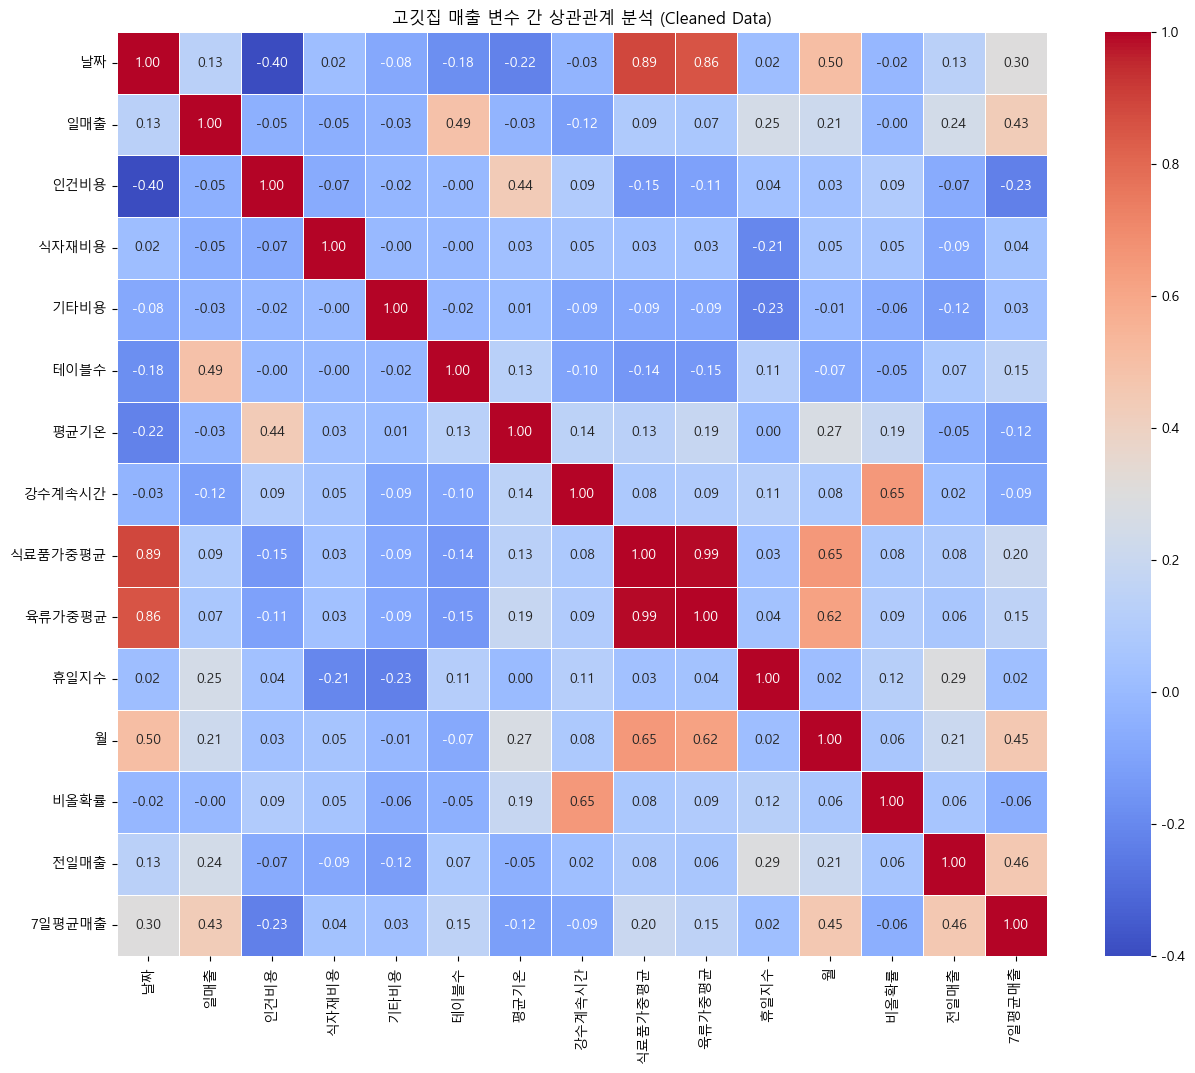

In [49]:
# 1. 상관계수 행렬 계산
corr_matrix = df.corr()

# 2. 히트맵 시각화
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('고깃집 매출 변수 간 상관관계 분석 (Cleaned Data)')
plt.show()

In [50]:
# !pip install xgboost

--- 모델 평가 결과 ---
R2 Score (설명력): 0.1838 (1에 가까울수록 완벽)
MAE (평균 절대 오차): 624,079원
RMSE (제곱근 평균 제곱 오차): 803,934원


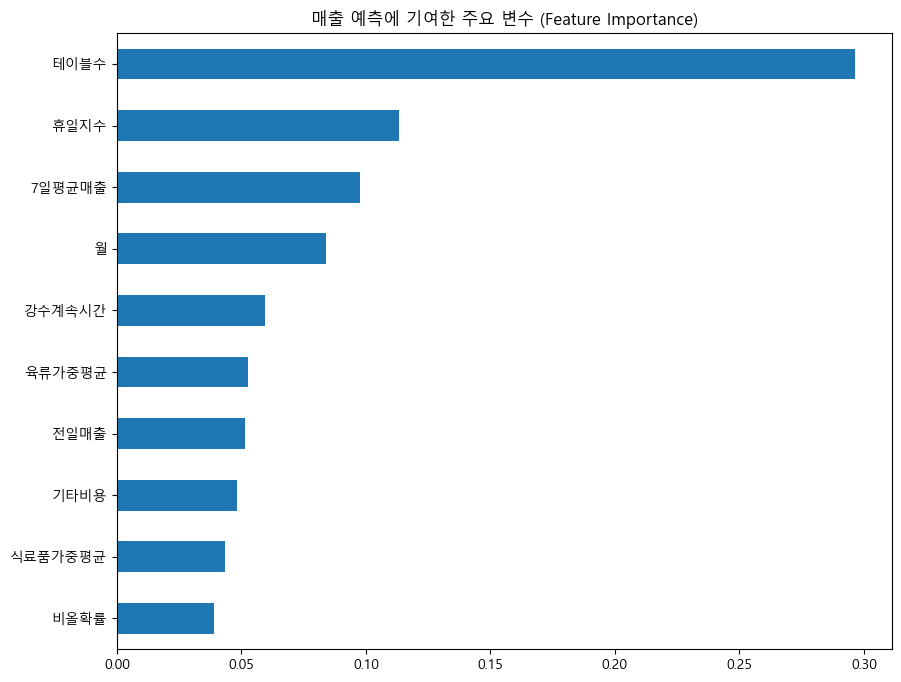

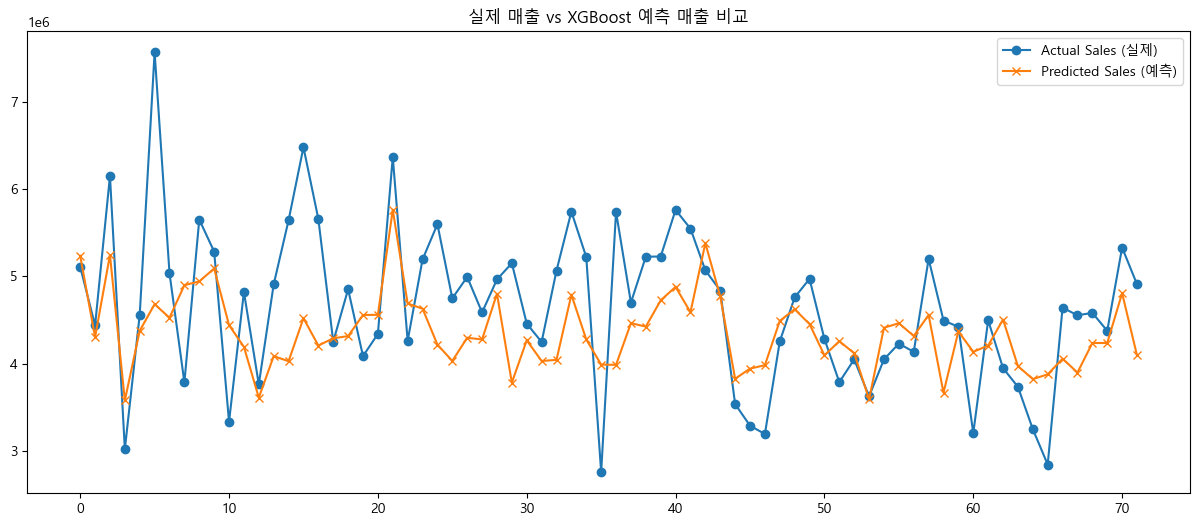

In [51]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 1. 학습에 사용할 피처(X)와 타겟(y) 설정
# 제외할 목록 : '날짜' -> 인덱스, '일매출' -> 종속변수 
features = ['인건비용', '식자재비용', '기타비용', '테이블수', '평균기온', '강수계속시간',
            '식료품가중평균', '육류가중평균','휴일지수', '월', '비올확률', '전일매출', '7일평균매출']

X = df[features]
y = df['일매출']

# 2. 학습/테스트 데이터 분리
# 과거 데이터로 미래를 예측 -> shuffle=False
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 3. XGBoost 모델 생성 및 학습
model = XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.01, 
    max_depth=5, 
    subsample=0.8, 
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# 4. 예측 및 성능 평가
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- 모델 평가 결과 ---")
print(f"R2 Score (설명력): {r2:.4f} (1에 가까울수록 완벽)")
print(f"MAE (평균 절대 오차): {mae:,.0f}원")
print(f"RMSE (제곱근 평균 제곱 오차): {rmse:,.0f}원")

# 5. 변수 중요도 시각화 (XGBoost가 무엇을 보고 판단했는가?)
plt.figure(figsize=(10, 8))
feat_importances = pd.Series(model.feature_importances_, index=features)
feat_importances.nlargest(10).sort_values().plot(kind='barh')
plt.title('매출 예측에 기여한 주요 변수 (Feature Importance)')
plt.show()

# 6. 실제 매출 vs 예측 매출 비교 그래프
plt.figure(figsize=(15, 6))
plt.plot(y_test.values, label='Actual Sales (실제)', marker='o')
plt.plot(y_pred, label='Predicted Sales (예측)', marker='x')
plt.title('실제 매출 vs XGBoost 예측 매출 비교')
plt.legend()
plt.show()

### 수정
성능적인면에서 많이 부족한 모습을 보임.

1. 월 데이터 -> 요일 데이터 더미화
    - 1년치의 데이터를 이용해서 학습과 검증이 들어가 있어 전체적인 월별 데이터에 대한 학습이 부족하다. 12월~1월은 연말회식, 연초 특성이 있음.
        - 2월~11월 : 학습 데이터
        - 12월~1월 : 검증 데이터
    - 월 데이터를 삭제하고 요일 데이터를 더미화 하여 사용했을때가 성능이 더 좋을 수 있음.
    
2. 2주평균매출, 4주평균매출, 7일전매출 파생변수 생성
    - 결측치 행 (28일치 삭제하기)
        - '데이터 28개가 사라지는 것'보다 '잘못된 데이터(0이나 임의의 값)가 들어가서 모델 학습을 방해하는 것'이 머신러닝에 훨씬 더 치명적일수 있음.
    - 점진적 윈도우 채우기 (데이터 버리지 않음)
        - pandas의 min_periods 옵션 사용하여 데이터가 28개가 안 되는 초반부에도 쌓인 데이터만큼만 가지고 임시 평균을 내줌.
        - 5일차에는 5일치 평균, 15일차에는 15일치 평균을 내다가, 28일차가 넘어가면 정상적으로 28일 평균을 계산하는 방식. 
        -> 결측치(NaN)가 단 한 행도 발생하지 않음

3. (★중요★)12월에 '연말특수지수' 파생변수 생성
    - 매장 위치 특성 고려(서울 시청역 -> 회사 회식多)
        - 회사는 평일에 출근 -> 목, 금에 회식이 많음
        - 토요일은 동호회 회식도 이루어짐.
    - 연말 (기준 : 2025년 12월 22일(월)이후) 단체 회식

In [52]:
# 1. 날짜 데이터 형식 확인 및 요일 추출 (0: 월요일, 6: 일요일)
df['요일'] = df['날짜'].dt.dayofweek

In [53]:
# 2. 요일 숫자를 문자열 이름으로 매핑 (더미 변수 컬럼명을 이쁘게 만들기 위함)
weekday_map = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}
df['요일'] = df['요일'].map(weekday_map)

In [54]:
# 3. 요일 데이터 더미화 (One-Hot Encoding)
# 다중공선성(Multicollinearity) 방지를 위해 drop_first=True를 쓸 수도 있으나, 
# 트리 기반 모델(XGBoost)은 그냥 모두 쓰는 것이 직관적이고 성능에 유리함.
df_dummies = pd.get_dummies(df['요일'], prefix='요일', dtype=int)

In [55]:
# 4. 기존 데이터프레임과 더미 변수 병합
df = pd.concat([df, df_dummies], axis=1)

In [56]:
# 5. 불필요해진 임시 컬럼 및 기존 '월' 컬럼 제거
df = df.drop(columns=['요일', '월'])

In [57]:
df.columns

Index(['날짜', '일매출', '인건비용', '식자재비용', '기타비용', '테이블수', '평균기온', '강수계속시간',
       '식료품가중평균', '육류가중평균', '휴일지수', '비올확률', '전일매출', '7일평균매출', '요일_금', '요일_목',
       '요일_수', '요일_월', '요일_일', '요일_토', '요일_화'],
      dtype='object')

In [58]:
features = ['인건비용', '식자재비용', '기타비용', '테이블수', '평균기온', '강수계속시간',
            '식료품가중평균', '육류가중평균', '휴일지수', '비올확률', '전일매출', '7일평균매출', '요일_금', '요일_목',
            '요일_수', '요일_월', '요일_일', '요일_토', '요일_화']

X = df[features]
y = df['일매출']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.01, 
    max_depth=5, 
    subsample=0.8, 
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- 모델 평가 결과 ---")
print(f"R2 Score (설명력): {r2:.4f} (1에 가까울수록 완벽)")
print(f"MAE (평균 절대 오차): {mae:,.0f}원")
print(f"RMSE (제곱근 평균 제곱 오차): {rmse:,.0f}원")

--- 모델 평가 결과 ---
R2 Score (설명력): 0.2257 (1에 가까울수록 완벽)
MAE (평균 절대 오차): 614,968원
RMSE (제곱근 평균 제곱 오차): 783,051원


#### 1. 결측치 행 (28일치 삭제하기)

In [59]:
final_df.head(5)

,날짜,일매출,인건비용,식자재비용,기타비용,테이블수,평균기온,강수계속시간,식료품가중평균,육류가중평균,휴일지수,월,비올확률,전일매출,7일평균매출
0,2025-02-01,4665000.0,866200.0,3030269,114800.0,62.0,1.6,0.00,119.04526,118.1,1,2,0,NaN,NaN
1,2025-02-02,2765500.0,814800.0,0,202200.0,40.0,1.5,0.08,119.04526,118.1,1,2,1,4665000.0,NaN
2,2025-02-03,2237000.0,850300.0,499818,66800.0,38.0,-4.1,0.00,119.04526,118.1,0,2,0,2765500.0,NaN
3,2025-02-04,4134000.0,824300.0,2915674,118600.0,59.0,-9.0,0.00,119.04526,118.1,0,2,0,2237000.0,NaN
4,2025-02-05,3536000.0,876300.0,1120400,228600.0,44.0,-8.6,0.00,119.04526,118.1,0,2,0,4134000.0,NaN


In [60]:
final_df.columns

Index(['날짜', '일매출', '인건비용', '식자재비용', '기타비용', '테이블수', '평균기온', '강수계속시간',
       '식료품가중평균', '육류가중평균', '휴일지수', '월', '비올확률', '전일매출', '7일평균매출'],
      dtype='object')

In [61]:
final_df['요일'] = final_df['날짜'].dt.dayofweek
weekday_map = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}
final_df['요일'] = final_df['요일'].map(weekday_map)
df_dummies = pd.get_dummies(final_df['요일'], prefix='요일', dtype=int)
final_df = pd.concat([final_df, df_dummies], axis=1)
final_df.drop(columns=['월', '요일'], axis = 1, inplace = True)

In [62]:
final_df2 = final_df.copy()

In [63]:
final_df2['전주매출'] = final_df2['일매출'].shift(7)

In [64]:
final_df2['14일평균매출'] = final_df2['일매출'].rolling(window=14).mean()
final_df2['28일평균매출'] = final_df2['일매출'].rolling(window=28).mean()

In [65]:
final_df2.dropna(inplace = True)

In [66]:
final_df2.reset_index(inplace = True)

In [67]:
final_df2.drop('index', axis = 1, inplace=True)

In [68]:
final_df2

,날짜,일매출,인건비용,식자재비용,기타비용,테이블수,평균기온,강수계속시간,식료품가중평균,육류가중평균,...,요일_금,요일_목,요일_수,요일_월,요일_일,요일_토,요일_화,전주매출,14일평균매출,28일평균매출
0,2025-02-28,4842000.0,824300.0,1788746,15700.0,56.0,7.8,0.00,119.045260,118.10,...,1,0,0,0,0,0,0,4447500.0,4.094607e+06,3.941607e+06
1,2025-03-01,6551500.0,707400.0,1920906,14200.0,104.0,8.5,1.50,118.379115,117.55,...,0,0,0,0,0,1,0,4322000.0,4.220179e+06,4.008982e+06
2,2025-03-02,4841000.0,707400.0,6400,14200.0,62.0,8.3,9.42,118.379115,117.55,...,0,0,0,0,1,0,0,4215500.0,4.293179e+06,4.083107e+06
3,2025-03-03,2536000.0,707400.0,2799563,107500.0,35.0,3.1,7.33,118.379115,117.55,...,0,0,0,1,0,0,0,3703500.0,4.234821e+06,4.093786e+06
4,2025-03-04,2190500.0,697400.0,1703956,26700.0,38.0,2.5,8.75,118.379115,117.55,...,0,0,0,0,0,0,1,3970500.0,4.144107e+06,4.024375e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,2026-01-27,4553600.0,633700.0,885628,148000.0,41.0,-4.4,0.00,125.447865,124.22,...,0,0,0,0,0,0,1,3204800.0,4.086129e+06,4.220414e+06
334,2026-01-28,4581800.0,635700.0,555890,135400.0,59.0,-5.4,0.00,125.447865,124.22,...,0,0,1,0,0,0,0,4496400.0,4.124157e+06,4.178336e+06
335,2026-01-29,4376500.0,484700.0,1854652,30000.0,59.0,-5.2,0.00,125.447865,124.22,...,0,1,0,0,0,0,0,3949000.0,4.134643e+06,4.136589e+06
336,2026-01-30,5328700.0,640200.0,2568562,31900.0,69.0,-6.4,0.00,125.447865,124.22,...,1,0,0,0,0,0,0,3735000.0,4.219857e+06,4.145882e+06


In [69]:
final_df2.columns

Index(['날짜', '일매출', '인건비용', '식자재비용', '기타비용', '테이블수', '평균기온', '강수계속시간',
       '식료품가중평균', '육류가중평균', '휴일지수', '비올확률', '전일매출', '7일평균매출', '요일_금', '요일_목',
       '요일_수', '요일_월', '요일_일', '요일_토', '요일_화', '전주매출', '14일평균매출', '28일평균매출'],
      dtype='object')

In [70]:
features = ['인건비용', '식자재비용', '기타비용', '테이블수', '평균기온', '강수계속시간',
            '식료품가중평균', '육류가중평균', '휴일지수', '비올확률', '전일매출', '7일평균매출', '요일_금', '요일_목',
            '요일_수', '요일_월', '요일_일', '요일_토', '요일_화', '전주매출' ,'14일평균매출', '28일평균매출']

X = final_df2[features]
y = final_df2['일매출']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.01, 
    max_depth=5, 
    subsample=0.8, 
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- 모델 평가 결과 ---")
print(f"R2 Score (설명력): {r2:.4f} (1에 가까울수록 완벽)")
print(f"MAE (평균 절대 오차): {mae:,.0f}원")
print(f"RMSE (제곱근 평균 제곱 오차): {rmse:,.0f}원")

--- 모델 평가 결과 ---
R2 Score (설명력): 0.2562 (1에 가까울수록 완벽)
MAE (평균 절대 오차): 581,485원
RMSE (제곱근 평균 제곱 오차): 753,175원


#### 2. 점진적 윈도우(Expanding/Minimum Periods) 채우기 (데이터를 한 장도 버리지 않는 방법)

In [71]:
final_df3 = final_df.copy()

In [72]:
final_df3.drop(columns = ['전일매출', '7일평균매출'], inplace = True)

In [73]:
final_df3['7일평균매출'] = final_df3['일매출'].rolling(window=7, min_periods=1).mean().shift(1)
final_df3['14일평균매출'] = final_df3['일매출'].rolling(window=14, min_periods=1).mean().shift(1)
final_df3['28일평균매출'] = final_df3['일매출'].rolling(window=28, min_periods=1).mean().shift(1)

In [74]:
final_df3['전일매출'] = final_df3['일매출'].shift(1)
final_df3['전주매출'] = final_df3['일매출'].shift(7)

In [75]:
final_df3['전주매출'] = final_df3['전주매출'].fillna(final_df3['전일매출'])

In [76]:
final_df3

,날짜,일매출,인건비용,식자재비용,기타비용,테이블수,평균기온,강수계속시간,식료품가중평균,육류가중평균,...,요일_수,요일_월,요일_일,요일_토,요일_화,7일평균매출,14일평균매출,28일평균매출,전일매출,전주매출
0,2025-02-01,4665000.0,866200.0,3030269,114800.0,62.0,1.6,0.00,119.045260,118.10,...,0,0,0,1,0,NaN,NaN,NaN,NaN,NaN
1,2025-02-02,2765500.0,814800.0,0,202200.0,40.0,1.5,0.08,119.045260,118.10,...,0,0,1,0,0,4.665000e+06,4.665000e+06,4.665000e+06,4665000.0,4665000.0
2,2025-02-03,2237000.0,850300.0,499818,66800.0,38.0,-4.1,0.00,119.045260,118.10,...,0,1,0,0,0,3.715250e+06,3.715250e+06,3.715250e+06,2765500.0,2765500.0
3,2025-02-04,4134000.0,824300.0,2915674,118600.0,59.0,-9.0,0.00,119.045260,118.10,...,0,0,0,0,1,3.222500e+06,3.222500e+06,3.222500e+06,2237000.0,2237000.0
4,2025-02-05,3536000.0,876300.0,1120400,228600.0,44.0,-8.6,0.00,119.045260,118.10,...,1,0,0,0,0,3.450375e+06,3.450375e+06,3.450375e+06,4134000.0,4134000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,2026-01-27,4553600.0,633700.0,885628,148000.0,41.0,-4.4,0.00,125.447865,124.22,...,0,0,0,0,1,3.731857e+06,4.019907e+06,4.244439e+06,4641200.0,3204800.0
361,2026-01-28,4581800.0,635700.0,555890,135400.0,59.0,-5.4,0.00,125.447865,124.22,...,1,0,0,0,0,3.924543e+06,4.086129e+06,4.220414e+06,4553600.0,4496400.0
362,2026-01-29,4376500.0,484700.0,1854652,30000.0,59.0,-5.2,0.00,125.447865,124.22,...,0,0,0,0,0,3.936743e+06,4.124157e+06,4.178336e+06,4581800.0,3949000.0
363,2026-01-30,5328700.0,640200.0,2568562,31900.0,69.0,-6.4,0.00,125.447865,124.22,...,0,0,0,0,0,3.997814e+06,4.134643e+06,4.136589e+06,4376500.0,3735000.0


In [77]:
final_df3.dropna(inplace = True)

In [78]:
features = ['인건비용', '식자재비용', '기타비용', '테이블수', '평균기온', '강수계속시간',
            '식료품가중평균', '육류가중평균', '휴일지수', '비올확률', '요일_금', '요일_목',
            '요일_수', '요일_월', '요일_일', '요일_토', '요일_화', '7일평균매출' ,'14일평균매출', '28일평균매출',
            '전일매출', '전주매출']

X = final_df3[features]
y = final_df3['일매출']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.01, 
    max_depth=5, 
    subsample=0.8, 
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- 모델 평가 결과 ---")
print(f"R2 Score (설명력): {r2:.4f} (1에 가까울수록 완벽)")
print(f"MAE (평균 절대 오차): {mae:,.0f}원")
print(f"RMSE (제곱근 평균 제곱 오차): {rmse:,.0f}원")

--- 모델 평가 결과 ---
R2 Score (설명력): 0.0025 (1에 가까울수록 완벽)
MAE (평균 절대 오차): 692,650원
RMSE (제곱근 평균 제곱 오차): 892,041원


#### 1번, 2번 활용 결과
- 단순히 평균치로 데이터를 채우는 것은 오히려 악영향으로 다가옴.
    - XGBoost 모델의 혼란
        - 모델에게 '28일평균매출'이라는 컬럼을 주면, 모델은 이 숫자를 "한 달간의 장기적이고 안정적인 매출 추세"라고 믿고 기준을 세워 학습함
        - 하지만 앞부분 28일 동안은 이 컬럼이 '한 달 평균'이 아니라 '하루~일주일 평균'이라는 완전히 다른 의미(노이즈)로 작동
        - 결과 : XGBoost는 앞부분 데이터에서 28일평균매출이 들쭉날쭉해 엉뚱한 규칙을 학습해 버렸고, 그 결과 전체 모델의 예측력이 완전히 무너져버림.
    - 어설픈 데이터 28장을 더하는 것보다, 확실하고 깨끗한 데이터 330장만 남기는 것이 훨씬 강력하다
- 1번의 final_df2를 활용

#### 3. 12월에 '연말특수지수' 파생변수 생성

In [79]:
final_df2['연말특수지수'] = 0

In [ ]:
# 1. 12월 조건 정의 (날짜 컬럼 활용)
is_december = final_df2['날짜'].dt.month == 12

# 2. 요일 조건 정의 (평일 목금은 회사 회식, 주말 토요일은 동호회, 모임 회식)
is_weekend_rush = (final_df2['요일_목'] == 1) | (final_df2['요일_금'] == 1) | (final_df2['요일_토'] == 1)

# 3. 연말 피크 시즌 조건 정의 (12월 22일 ~ 31일)
is_end_of_year = final_df2['날짜'].dt.day >= 22

# 4. 조건 결합하여 연말특수지수를 1로 채우기
# 조건 A: 12월이면서 평일
final_df2.loc[is_december & is_weekend_rush, '연말특수지수'] = 1

# 조건 B: 12월이면서 22일~31일 (대관 및 연말 예약 폭주 기간)
final_df2.loc[is_december & is_end_of_year, '연말특수지수'] = 1

--- 모델 평가 결과 ---
R2 Score (설명력): 0.5061 (1에 가까울수록 완벽)
MAE (평균 절대 오차): 438,038원
RMSE (제곱근 평균 제곱 오차): 546,904원


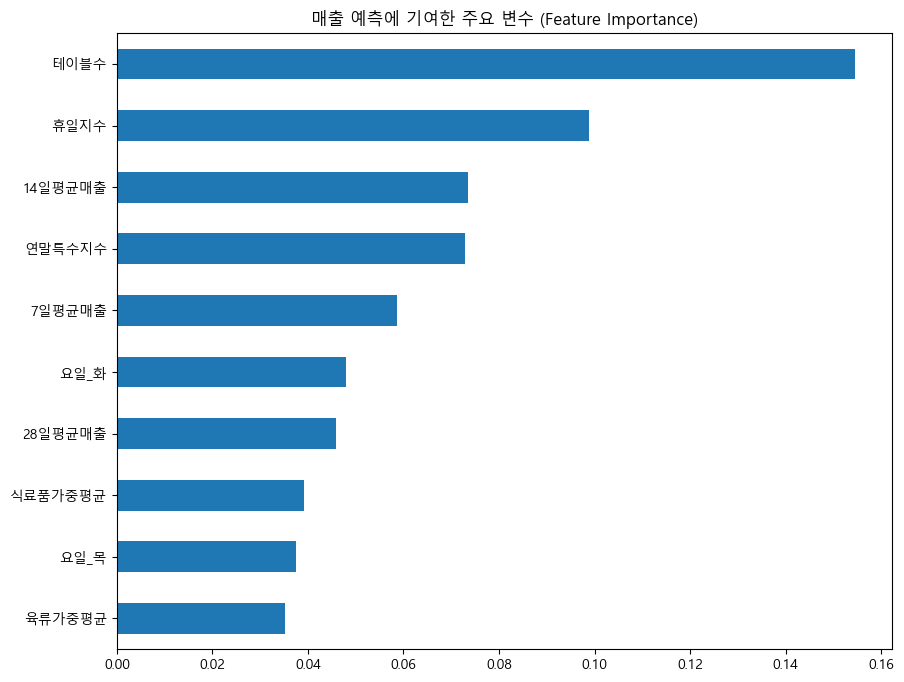

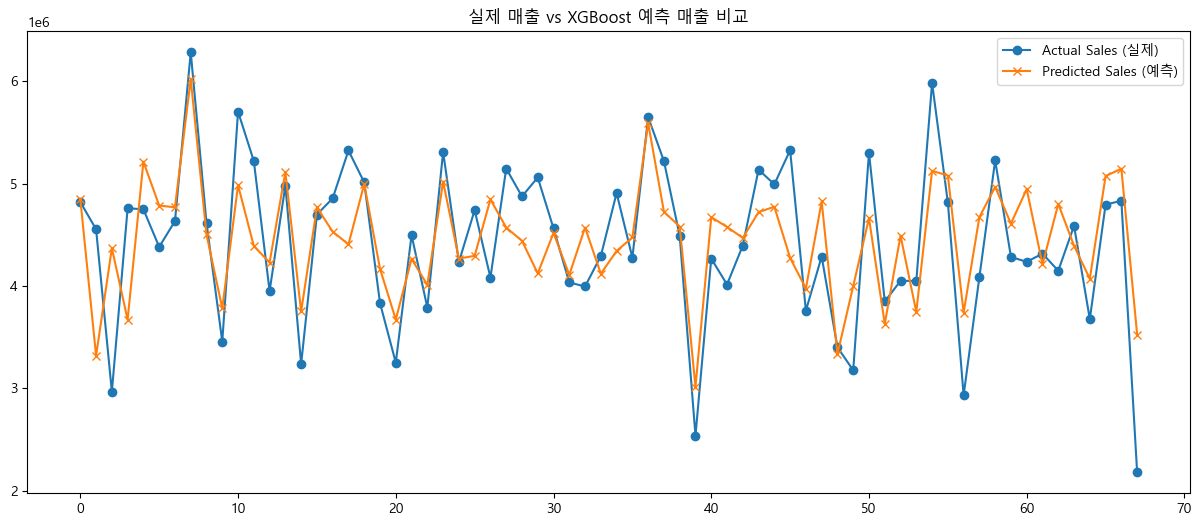

In [81]:
features = ['인건비용', '식자재비용', '기타비용', '테이블수', '평균기온', '강수계속시간',
            '식료품가중평균', '육류가중평균', '휴일지수', '비올확률', '전일매출', '7일평균매출', '요일_금', '요일_목',
            '요일_수', '요일_월', '요일_일', '요일_토', '요일_화', '전주매출' ,'14일평균매출', '28일평균매출', '연말특수지수']

X = final_df2[features]
y = final_df2['일매출']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

model = XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.01, 
    max_depth=5,
    subsample=0.8, 
    colsample_bytree=0.8,
    n_jobs=-1, 
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- 모델 평가 결과 ---")
print(f"R2 Score (설명력): {r2:.4f} (1에 가까울수록 완벽)")
print(f"MAE (평균 절대 오차): {mae:,.0f}원")
print(f"RMSE (제곱근 평균 제곱 오차): {rmse:,.0f}원")

plt.figure(figsize=(10, 8))
feat_importances = pd.Series(model.feature_importances_, index=features)
feat_importances.nlargest(10).sort_values().plot(kind='barh')
plt.title('매출 예측에 기여한 주요 변수 (Feature Importance)')
plt.show()


plt.figure(figsize=(15, 6))
plt.plot(y_test.values, label='Actual Sales (실제)', marker='o')
plt.plot(y_pred, label='Predicted Sales (예측)', marker='x')
plt.title('실제 매출 vs XGBoost 예측 매출 비교')
plt.legend()
plt.show()